In [15]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict , Literal  , Union , List , Optional
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel , Field
load_dotenv()


True

In [17]:
class ReportCardState(TypedDict):
    marks : dict
    total_marks :float
    percentage :  float
    grade :  str 


In [20]:
def calculate_stats(state : ReportCardState) -> ReportCardState:
    # extract the marks 
    marks = state['marks']
    
    # sum the marks 
    total = sum(marks.values())
    
    # find percentage
    subjects = len(marks.values())
    percentage = total/ subjects
    # update stats 
    state['total_marks'] = total
    state['percentage'] = percentage
    return state


def assign_grade(state:  ReportCardState ) -> ReportCardState:
    status = state['percentage']
    
    # condition follow  
    if status >= 90:
        grade = "A"
    elif status >= 75:
        grade = "B"
    elif status >= 50:
        grade = "C"
    else:
        grade = 'Compartment'
    
    # update stats 
    state['grade'] = grade
    
    return state 


In [22]:
graph = StateGraph(ReportCardState)

graph.add_node("calculate_stats" , calculate_stats)
graph.add_node("assign_grade" , assign_grade)

graph.add_edge(START , "calculate_stats")
graph.add_edge("calculate_stats" , "assign_grade")
graph.add_edge("assign_grade" , END)

workflow = graph.compile()


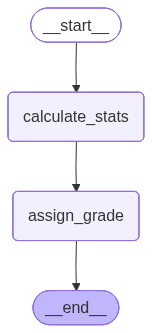

In [23]:
workflow


In [35]:
intial_state = { "marks":{
    "math" : 96, 
    "physics" : 67,
    "chemistry" : 56,
    "python" : 90,
    "cpp programming" : 85, 
    "DSA" :80, 
    "OOP"  : 85 
}
}

final_state = workflow.invoke(intial_state)


In [36]:
print(final_state)


{'marks': {'math': 96, 'physics': 67, 'chemistry': 56, 'python': 90, 'cpp programming': 85, 'DSA': 80, 'OOP': 85}, 'total_marks': 559, 'percentage': 79.85714285714286, 'grade': 'B'}
